In [152]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [153]:
df=pd.read_csv(r"C:\Users\anant\Desktop\Salary_Data.csv")
df

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0
5,2.9,56642.0
6,3.0,60150.0
7,3.2,54445.0
8,3.2,64445.0
9,3.7,57189.0


In [154]:
print(df.head())
print(df.info())
print(df.describe())

   YearsExperience   Salary
0              1.1  39343.0
1              1.3  46205.0
2              1.5  37731.0
3              2.0  43525.0
4              2.2  39891.0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 612.0 bytes
None
       YearsExperience         Salary
count        30.000000      30.000000
mean          5.313333   76003.000000
std           2.837888   27414.429785
min           1.100000   37731.000000
25%           3.200000   56720.750000
50%           4.700000   65237.000000
75%           7.700000  100544.750000
max          10.500000  122391.000000


Exploratory Data Analysis (EDA)

️⃣ Check for Missing Values

YearsExperience    0
Salary             0
dtype: int64


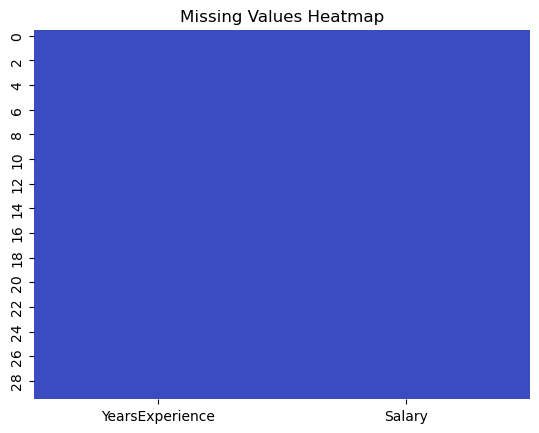

In [157]:
print(df.isnull().sum())
sns.heatmap(df.isnull(), cbar=False, cmap='coolwarm')
plt.title("Missing Values Heatmap")
plt.show()


In [158]:
# we can conclude no missing values

In [159]:
# Summary Statistics

In [160]:
print(df.describe())


       YearsExperience         Salary
count        30.000000      30.000000
mean          5.313333   76003.000000
std           2.837888   27414.429785
min           1.100000   37731.000000
25%           3.200000   56720.750000
50%           4.700000   65237.000000
75%           7.700000  100544.750000
max          10.500000  122391.000000


In [161]:
# checking the correlation

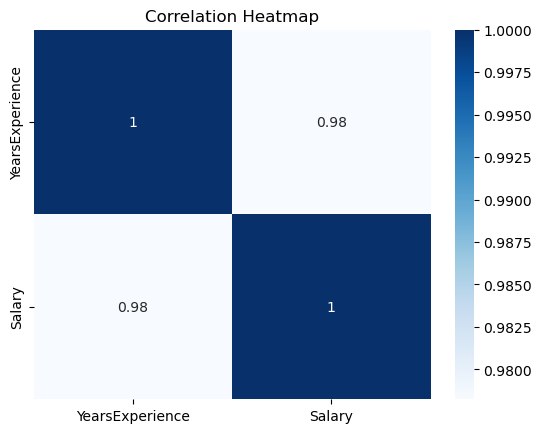

In [162]:
sns.heatmap(df.corr(), annot=True, cmap='Blues')
plt.title("Correlation Heatmap")
plt.show()


In [163]:
# it shows high positive correlation

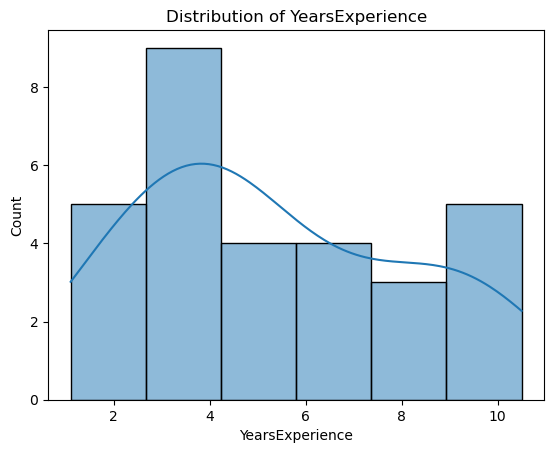

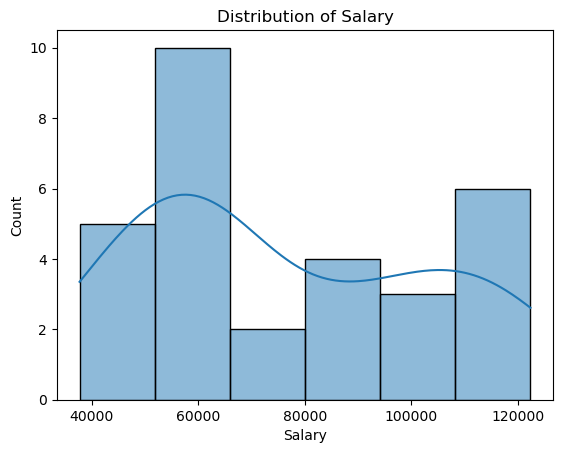

In [164]:
for col in df.columns:
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()


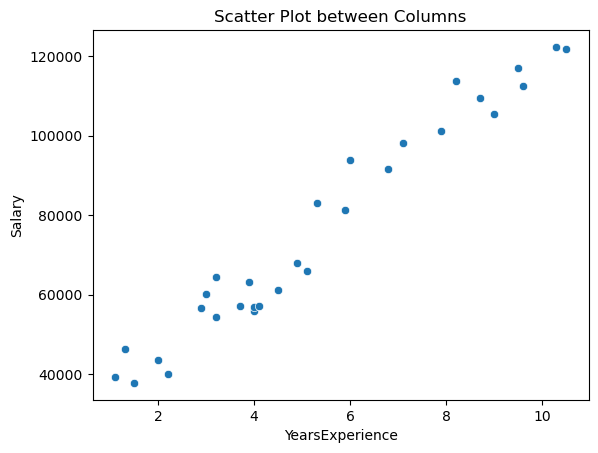

In [165]:
sns.scatterplot(x=df.columns[0], y=df.columns[1], data=df)
plt.title("Scatter Plot between Columns")
plt.show()


In [166]:
df["Salary"].mean()

76003.0

In [167]:
#it shows a linear relationship thus linear 

Scaling

In [169]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)

print(df_scaled.head())


   YearsExperience    Salary
0        -1.510053 -1.360113
1        -1.438373 -1.105527
2        -1.366693 -1.419919
3        -1.187494 -1.204957
4        -1.115814 -1.339781


In [170]:
df_scaled["Salary"].mean()

1.4802973661668754e-17

In [171]:
df["Salary"].mean()

76003.0

In [172]:
df["YearsExperience"].mean()

5.3133333333333335

In [173]:
df_scaled["YearsExperience"].mean()

-7.401486830834377e-18

In [261]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

In [263]:
X = df_scaled[['YearsExperience']]   # Independent variable(s)
y = df_scaled['Salary']      # Dependent variable


In [265]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [267]:
model = LinearRegression(
    
)
model.fit(X_train, y_train)


LinearRegression()

In [269]:
y_pred=model.predict(X_test)
y_pred

array([ 1.47613439, -0.16712845,  0.98665184, -0.0272763 , -0.76150012,
       -0.58668493])

In [271]:
X_test #used for training

,YearsExperience
27,1.536336
15,-0.148138
23,1.034577
17,-0.004779
8,-0.757416
9,-0.578216


In [273]:
y_test #used for testing

27    1.359074
15   -0.299217
23    1.402741
17    0.262859
8    -0.428810
9    -0.698013
Name: Salary, dtype: float64

In [275]:
print("R² Score:", r2_score(y_test, y_pred))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))


R² Score: 0.9024461774180498
Mean Squared Error: 0.06858932896507035


In [ ]:
#mean squre is used to find the differnce between actual and predicted good model should predict near to 0

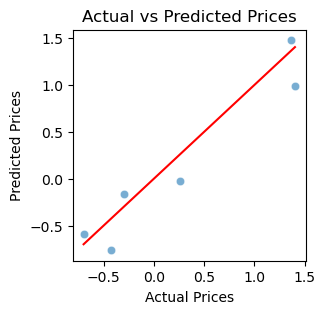

In [277]:
import seaborn as sns

# Visualizing the regression results
plt.figure(figsize=(3,3))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
sns.lineplot(x=[y_test.min(), y_test.max()], y=[y_test.min(), y_test.max()], color='red')
plt.title('Actual vs Predicted Prices')
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.show()

In [286]:
# model Evaluvation

In [288]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

model = LinearRegression()
model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Evaluate performance
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("Training R²:", train_r2)
print("Testing R²:", test_r2)


Training R²: 0.9645401573418148
Testing R²: 0.9024461774180498


In [290]:
from sklearn.metrics import mean_squared_error

# Predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Calculate MSE
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

print("Training MSE:", train_mse)
print("Testing MSE:", test_mse)


Training MSE: 0.03730526809703687
Testing MSE: 0.06858932896507035


In [1]:
import numpy as np
rmse = np.sqrt(0.3543)
print("RMSE:", rmse)


RMSE: 0.5952310475773253


In [292]:
#here model perform well in training but compare less in testing so it is overfitting

In [295]:
# 2 Using Lasso Regression

In [297]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Initialize model with alpha value (regularization strength)
lasso = Lasso(alpha=0.1, random_state=42)

# Fit model
lasso.fit(X_train, y_train)

# Predictions
y_train_pred = lasso.predict(X_train)
y_test_pred = lasso.predict(X_test)


In [299]:
# Model evaluvation

In [301]:
# Calculate MSE
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

# R² Scores
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("Training MSE:", train_mse)
print("Testing MSE:", test_mse)
print("Training R²:", train_r2)
print("Testing R²:", test_r2)


Training MSE: 0.046683737718049796
Testing MSE: 0.07863769325638341
Training R²: 0.9556256239769653
Testing R²: 0.8881545031575717


In [303]:
# Comparing lasso with linear regression

In [305]:
print("Linear Regression Test MSE:", mean_squared_error(y_test, model.predict(X_test)))
print("Lasso Regression Test MSE:", test_mse)


Linear Regression Test MSE: 0.06858932896507035
Lasso Regression Test MSE: 0.07863769325638341


In [ ]:
#here we find out by comparing the mse of lasso and linear regression linear regression's mse is near to 0 
#Thus Linear Regression is better than Lasso Regression